# 📉 Class 9.1 — Backpropagation & Loss Functions
### 301 – Machine Learning Techniques

---

**Learning Goals:**
- Understand what a loss function measures and which to use for which problem
- Implement gradient descent from scratch to minimise a simple function
- See how learning rate affects convergence
- Understand what backpropagation does (conceptually)

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
np.random.seed(42)
print('✅ Ready')

✅ Ready


---
## Part 1 — Loss Functions

A loss function measures how wrong our predictions are. During training, the goal is to minimise the loss.

| Problem Type | Loss Function | Formula |
|---|---|---|
| Regression | **MSE** (Mean Squared Error) | (1/n) Σ(y_true - y_pred)² |
| Binary classification | **Binary Cross-Entropy** | -(1/n) Σ[y·log(p) + (1-y)·log(1-p)] |
| Multiclass classification | **Categorical Cross-Entropy** | -(1/n) Σ Σ y_ij · log(p_ij) |

**Why squared in MSE?** To make all errors positive AND to penalise large errors more heavily than small ones.

In [2]:
# Implement the three main loss functions

def mse_loss(y_true, y_pred):
    """Mean Squared Error — for regression"""
    # HINT: np.mean((y_true - y_pred) ** 2)
    return np.mean((y_true - y_pred) ** 2)

def binary_cross_entropy(y_true, y_pred):
    """
    Binary Cross-Entropy — for binary classification
    y_pred must be probabilities between 0 and 1 (sigmoid output)
    """
    # Clip predictions to avoid log(0) which is -infinity
    y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)
    # HINT: -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Test the loss functions
y_true_reg  = np.array([3.0, 5.0, 2.0, 8.0])
y_pred_good = np.array([3.1, 4.9, 2.1, 7.9])  # close predictions
y_pred_bad  = np.array([1.0, 8.0, 5.0, 2.0])  # poor predictions

print('=== MSE Loss ===')
print(f'Good predictions MSE: {mse_loss(y_true_reg, y_pred_good):.4f}  (should be small)')
print(f'Bad predictions MSE:  {mse_loss(y_true_reg, y_pred_bad):.4f}  (should be large)')
print()

y_true_cls  = np.array([1, 0, 1, 1, 0])
y_prob_good = np.array([0.9, 0.1, 0.8, 0.7, 0.2])  # confident and correct
y_prob_bad  = np.array([0.1, 0.9, 0.2, 0.3, 0.8])  # confident and wrong

print('=== Binary Cross-Entropy Loss ===')
print(f'Good predictions BCE: {binary_cross_entropy(y_true_cls, y_prob_good):.4f}  (should be small)')
print(f'Bad predictions BCE:  {binary_cross_entropy(y_true_cls, y_prob_bad):.4f}  (should be large)')


=== MSE Loss ===
Good predictions MSE: 0.0100  (should be small)
Bad predictions MSE:  14.5000  (should be large)

=== Binary Cross-Entropy Loss ===
Good predictions BCE: 0.2027  (should be small)
Bad predictions BCE:  1.8056  (should be large)


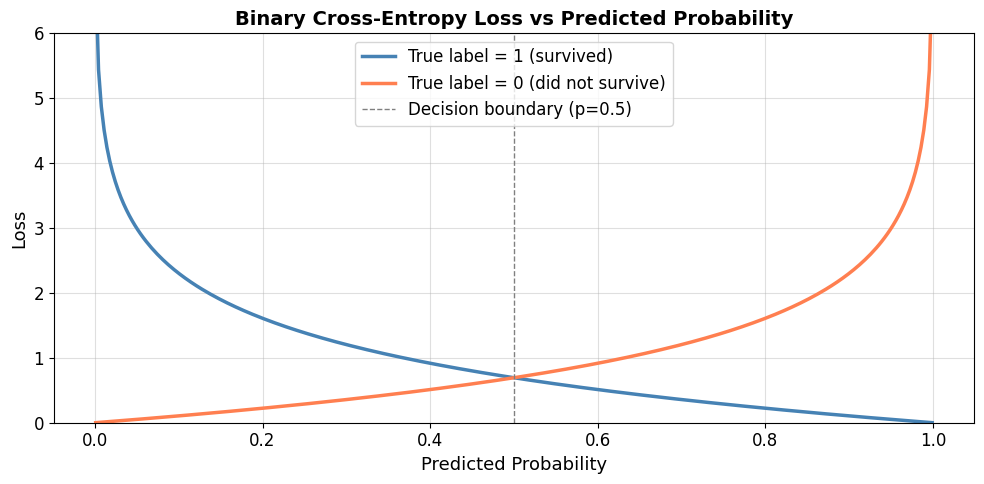

Key insight: For a TRUE POSITIVE example (survived=1),
the loss SKYROCKETS when you predict p=0.01 (nearly zero).
The model is heavily punished for being confidently WRONG.


In [3]:
# Visualise how BCE loss changes with predicted probability
# For a POSITIVE example (y_true = 1), what happens as our predicted probability varies?

p_range = np.linspace(0.001, 0.999, 300)  # predicted probabilities from near 0 to near 1

# Loss for a TRUE POSITIVE (y_true=1)
# When y_true=1, BCE = -log(p_pred) → loss is LOW when p_pred is HIGH
loss_positive = -np.log(p_range)

# Loss for a TRUE NEGATIVE (y_true=0)
# When y_true=0, BCE = -log(1 - p_pred) → loss is LOW when p_pred is LOW
loss_negative = -np.log(1 - p_range)

plt.figure(figsize=(10, 5))
plt.plot(p_range, loss_positive, color='steelblue', linewidth=2.5, label='True label = 1 (survived)')
plt.plot(p_range, loss_negative, color='coral', linewidth=2.5, label='True label = 0 (did not survive)')
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Decision boundary (p=0.5)')
plt.xlabel('Predicted Probability', fontsize=13)
plt.ylabel('Loss', fontsize=13)
plt.title('Binary Cross-Entropy Loss vs Predicted Probability', fontsize=14, fontweight='bold')
plt.ylim(0, 6)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('Key insight: For a TRUE POSITIVE example (survived=1),')
print('the loss SKYROCKETS when you predict p=0.01 (nearly zero).')
print('The model is heavily punished for being confidently WRONG.')

---
## Part 2 — Gradient Descent from Scratch

**The big question:** If loss measures how wrong we are, how do we get less wrong?

Answer: **Gradient Descent** — move the parameters in the direction that decreases the loss.

**Analogy:** Imagine you're blindfolded on a hilly landscape. You want to reach the lowest valley. You can only feel the slope under your feet. Gradient descent takes small steps always pointing downhill.

**The update rule:**
```
parameter = parameter - learning_rate × gradient
```

The **gradient** is the derivative — it tells you which direction is "uphill".
We subtract it because we want to go downhill (minimise loss).
The **learning rate** controls step size — too small = slow, too large = overshoot.

In [4]:
# ── EXERCISE 1: Minimise a simple parabola y = (x - 3)² ──────────────────
# We know the minimum is at x = 3 (where y = 0)
# Can gradient descent find it automatically?

# The loss function
def loss_fn(x):
    return (x - 3) ** 2

# The gradient (derivative) of the loss with respect to x
# d/dx [(x-3)²] = 2(x-3)
def gradient(x):
    return 2 * (x - 3)

# Run gradient descent
x = -2.0          # starting point (far from the minimum)
learning_rate = 0.1
n_steps = 30

history_x    = [x]
history_loss = [loss_fn(x)]

for step in range(n_steps):
    grad = gradient(x)                       # compute the gradient at current x
    x = x - learning_rate * grad             # HINT: x = x - learning_rate * grad
    history_x.append(x)
    history_loss.append(loss_fn(x))

print(f'Starting x: -2.0,  Starting loss: {loss_fn(-2.0):.2f}')
print(f'Final x:   {x:.6f},  Final loss: {loss_fn(x):.6f}')
print(f'True minimum: x = 3.0, loss = 0.0')


Starting x: -2.0,  Starting loss: 25.00
Final x:   2.993810,  Final loss: 0.000038
True minimum: x = 3.0, loss = 0.0


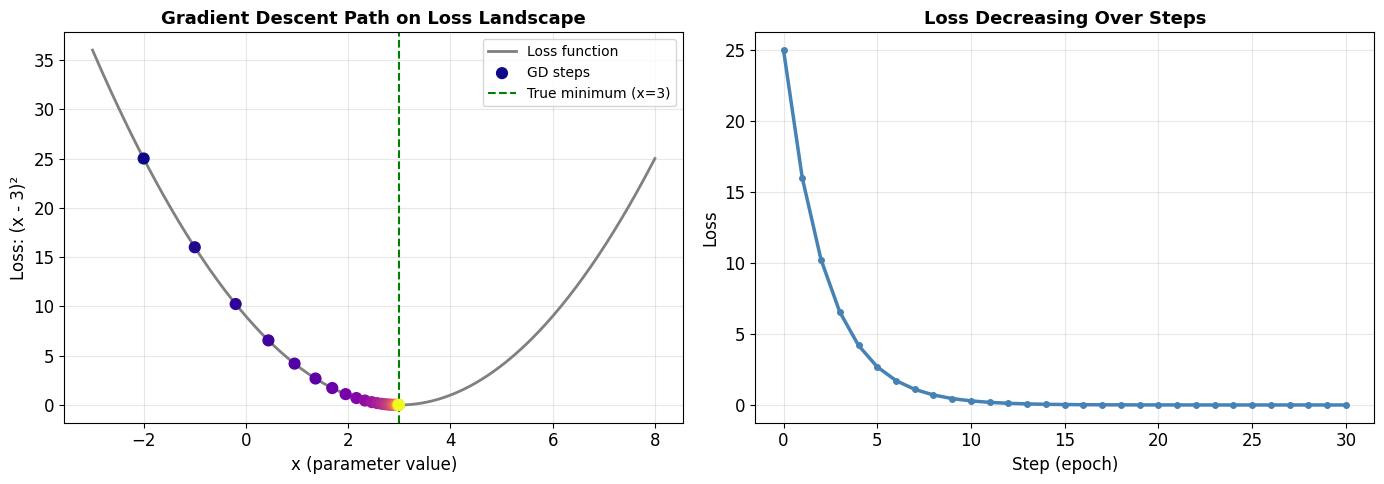

In [5]:
# Visualise the gradient descent path
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: loss landscape with path
x_range = np.linspace(-3, 8, 300)
axes[0].plot(x_range, loss_fn(x_range), 'gray', linewidth=2, label='Loss function')
axes[0].scatter(history_x, [loss_fn(xi) for xi in history_x],
                c=range(len(history_x)), cmap='plasma', s=60, zorder=5, label='GD steps')
axes[0].set_xlabel('x (parameter value)', fontsize=12)
axes[0].set_ylabel('Loss: (x - 3)²', fontsize=12)
axes[0].set_title('Gradient Descent Path on Loss Landscape', fontsize=13, fontweight='bold')
axes[0].axvline(3, color='green', linestyle='--', label='True minimum (x=3)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: loss over steps
axes[1].plot(history_loss, color='steelblue', linewidth=2.5, marker='o', markersize=4)
axes[1].set_xlabel('Step (epoch)', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Loss Decreasing Over Steps', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 3 — Learning Rate Comparison

The learning rate is one of the most important hyperparameters in deep learning.
- **Too small** → takes forever to converge
- **Too large** → overshoots the minimum, may diverge
- **Just right** → converges efficiently


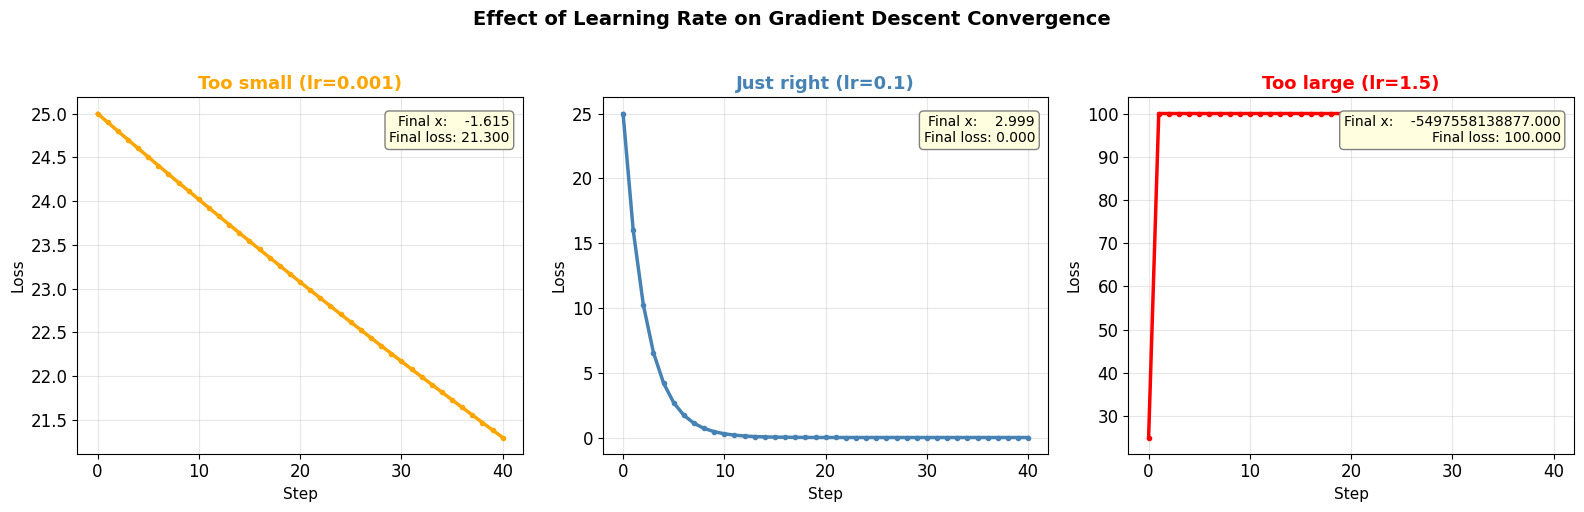

Observations:
lr=0.001: converges but very slowly — still far from minimum after 40 steps
lr=0.1:   converges smoothly — reaches near-zero loss quickly
lr=1.5:   overshoots — bounces past the minimum, loss may even increase!


In [6]:
def run_gradient_descent(start_x, learning_rate, n_steps=40):
    """Run gradient descent and return history of x and loss values"""
    x = start_x
    history_x    = [x]
    history_loss = [loss_fn(x)]
    for _ in range(n_steps):
        grad = gradient(x)
        x = x - learning_rate * grad
        history_x.append(x)
        history_loss.append(loss_fn(x))
    return history_x, history_loss

# Run with three different learning rates
lrs = [
    (0.001, 'Too small (lr=0.001)', 'orange'),
    (0.1,   'Just right (lr=0.1)',  'steelblue'),
    (1.5,   'Too large (lr=1.5)',   'red'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (lr, label, color) in zip(axes, lrs):
    hist_x, hist_loss = run_gradient_descent(start_x=-2.0, learning_rate=lr, n_steps=40)

    # Clip loss for display (diverging LR can go to infinity)
    hist_loss_clipped = [min(l, 100) for l in hist_loss]

    ax.plot(hist_loss_clipped, color=color, linewidth=2.5, marker='o', markersize=3)
    ax.set_title(label, fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('Step', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.grid(True, alpha=0.3)

    final_x    = hist_x[-1]
    final_loss = hist_loss[-1]
    ax.text(0.97, 0.95, f'Final x:    {final_x:.3f}\nFinal loss: {min(final_loss, 100):.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))

plt.suptitle('Effect of Learning Rate on Gradient Descent Convergence',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Observations:')
print('lr=0.001: converges but very slowly — still far from minimum after 40 steps')
print('lr=0.1:   converges smoothly — reaches near-zero loss quickly')
print('lr=1.5:   overshoots — bounces past the minimum, loss may even increase!')

---
## Part 4 — Gradient Descent on a Real Regression Problem

Now let's use gradient descent to actually fit a line to data — this is essentially what linear regression does, but we'll do it manually to see the gradient updates.

In [7]:
# Generate a tiny regression dataset: 5 points on a noisy line
np.random.seed(7)
X_reg = np.array([1.0, 2.0, 3.0, 4.0, 5.0])  # input feature
y_reg = np.array([2.1, 3.9, 6.2, 7.8, 10.1]) # noisy target (true: y ≈ 2x)

# We want to learn: y = w * x + b
# We start with random w and b
w = 0.0   # slope (weight)
b = 0.0   # intercept (bias)
learning_rate = 0.01
n_epochs = 100

loss_history = []
snapshot_steps = [0, 5, 20, 99]  # record these epochs for plotting
snapshots = []

for epoch in range(n_epochs):
    # Forward pass: compute predictions
    y_pred = w * X_reg + b

    # Compute MSE loss
    loss = mse_loss(y_reg, y_pred)
    loss_history.append(loss)

    # Compute gradients
    # dL/dw = (2/n) Σ (y_pred - y_true) * x
    # dL/db = (2/n) Σ (y_pred - y_true)
    n = len(X_reg)
    dw = (2/n) * np.sum((y_pred - y_reg) * X_reg)
    db = (2/n) * np.sum(y_pred - y_reg)

    # Update parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if epoch in snapshot_steps:
        snapshots.append((epoch, w, b, loss))

print(f'Final w: {w:.4f}  (true: ~2.0)')
print(f'Final b: {b:.4f}  (true: ~0.0)')
print(f'Final loss: {loss_history[-1]:.4f}')


Final w: 1.8981  (true: ~2.0)
Final b: 0.3818  (true: ~0.0)
Final loss: 0.0416


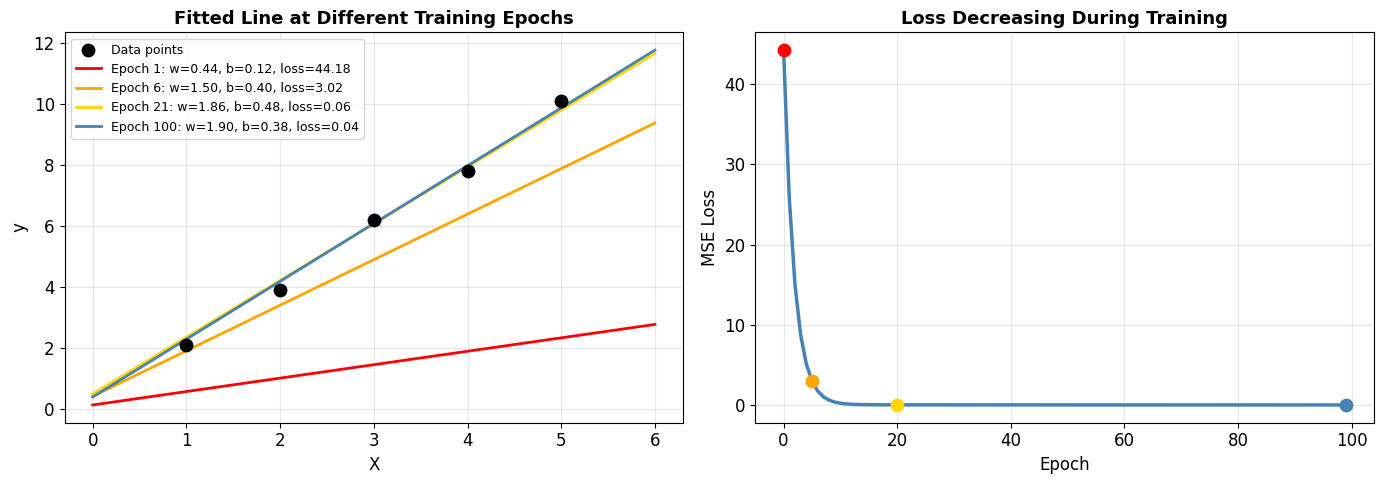

In [8]:
# Visualise the fitting process
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: show fitted lines at different epochs
x_line = np.linspace(0, 6, 100)
colors_snap = ['red', 'orange', 'gold', 'steelblue']

axes[0].scatter(X_reg, y_reg, color='black', s=80, zorder=5, label='Data points')
for (epoch, w_snap, b_snap, loss_snap), color in zip(snapshots, colors_snap):
    y_line = w_snap * x_line + b_snap
    axes[0].plot(x_line, y_line, color=color, linewidth=2,
                 label=f'Epoch {epoch+1}: w={w_snap:.2f}, b={b_snap:.2f}, loss={loss_snap:.2f}')

axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].set_title('Fitted Line at Different Training Epochs', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: loss curve
axes[1].plot(loss_history, color='steelblue', linewidth=2.5)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MSE Loss', fontsize=12)
axes[1].set_title('Loss Decreasing During Training', fontsize=13, fontweight='bold')
for (epoch, w_snap, b_snap, loss_snap), color in zip(snapshots, colors_snap):
    axes[1].scatter([epoch], [loss_snap], color=color, s=80, zorder=5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 5 — Backpropagation: The Conceptual Picture

In a neural network with many layers, we need to compute the gradient for EVERY weight — not just w and b of a simple line. Backpropagation does this efficiently using the **chain rule** from calculus.

**Intuition:**
- Forward pass computes the prediction (and the loss)
- Backward pass computes how much EACH weight contributed to the loss
- We then update all weights simultaneously

**The good news:** In Keras/TensorFlow, this is done automatically. You never implement backprop yourself in production. But understanding it helps you debug.

Run the cell below to see what backprop outputs look like conceptually.

In [9]:
# This cell shows what backprop computes — the gradients
# We reuse our 2-layer numpy network from Class 7.3

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

# Re-define weights and sample
np.random.seed(42)
X_sample = np.array([[22.0, 7.25, 1, 3]])  # 1 passenger, 4 features
y_sample  = np.array([[0]])                  # did not survive

W1 = np.random.randn(4, 3) * 0.1
b1 = np.zeros((1, 3))
W2 = np.random.randn(3, 1) * 0.1
b2 = np.zeros((1, 1))

# Forward pass
Z1 = X_sample @ W1 + b1
A1 = relu(Z1)
Z2 = A1 @ W2 + b2
A2 = sigmoid(Z2)   # prediction

bce = binary_cross_entropy(y_sample, A2)
print(f'Prediction: {A2[0,0]:.4f}   (True label: 0)')
print(f'Loss (BCE): {bce:.4f}')
print()

# ── BACKWARD PASS (manual for educational purposes) ───────────────────────
# Output layer gradient
dA2 = -(y_sample / np.clip(A2, 1e-9, 1) - (1 - y_sample) / np.clip(1 - A2, 1e-9, 1))
dZ2 = dA2 * A2 * (1 - A2)          # sigmoid derivative
dW2 = A1.T @ dZ2                    # gradient for W2
db2 = np.sum(dZ2, axis=0, keepdims=True)

# Hidden layer gradient (chain rule)
dA1 = dZ2 @ W2.T
dZ1 = dA1 * (Z1 > 0).astype(float) # ReLU derivative: 1 if Z>0, else 0
dW1 = X_sample.T @ dZ1             # gradient for W1
db1 = np.sum(dZ1, axis=0, keepdims=True)

print('Gradients computed by backpropagation:')
print(f'  dW2 (gradient for output weights): {dW2.flatten().round(4)}')
print(f'  dW1 (gradient for hidden weights, first row): {dW1[0].round(4)}')
print()
print('These gradients tell us: "move W1 and W2 in this direction to reduce the loss"')
print()

# Perform ONE gradient descent step
lr = 0.1
W2_new = W2 - lr * dW2
W1_new = W1 - lr * dW1

# Compute loss after one step
Z1_new = X_sample @ W1_new + b1
A1_new = relu(Z1_new)
Z2_new = A1_new @ W2_new + b2
A2_new = sigmoid(Z2_new)
bce_new = binary_cross_entropy(y_sample, A2_new)

print(f'Loss BEFORE update: {bce:.6f}')
print(f'Loss AFTER one step: {bce_new:.6f}')
print(f'Loss decreased by: {bce - bce_new:.6f}  ← backprop + gradient descent working!')

Prediction: 0.4692   (True label: 0)
Loss (BCE): 0.6334

Gradients computed by backpropagation:
  dW2 (gradient for output weights): [1.1813 0.     0.5013]
  dW1 (gradient for hidden weights, first row): [ 0.2498  0.     -1.7805]

These gradients tell us: "move W1 and W2 in this direction to reduce the loss"

Loss BEFORE update: 0.633354
Loss AFTER one step: 0.220251
Loss decreased by: 0.413103  ← backprop + gradient descent working!


---
## ✅ Notebook Complete!

**What you implemented today:**
- MSE loss and Binary Cross-Entropy loss from scratch
- Gradient descent: the update rule `w = w - lr × gradient`
- Learning rate comparison: too small, just right, too large
- Manual linear regression via gradient descent
- One full backward pass through a 2-layer network

**Key insight to remember:** In Keras, all of this is handled automatically by `model.compile(optimizer='adam', loss='binary_crossentropy')`. But now you understand what's happening under the hood.

**Coming up:** We plug all of this into Keras and build our first real neural network in 5 lines of code.